In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

import numpy as np
from typing import Iterable, Tuple, Optional

import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [25]:
data = pd.read_csv('Trips_2018/Trips_2018.csv')
print(data.head())

   Unnamed: 0  tripduration                 starttime  \
0           0           970  2018-01-01 13:50:57.4340   
1           1           723  2018-01-01 15:33:30.1820   
2           2           496  2018-01-01 15:39:18.3370   
3           3           306  2018-01-01 15:40:13.3720   
4           4           306  2018-01-01 18:14:51.5680   

                   stoptime  start_station_id  start_station_latitude  \
0  2018-01-01 14:07:08.1860              72.0               40.767272   
1  2018-01-01 15:45:33.3410              72.0               40.767272   
2  2018-01-01 15:47:35.1720              72.0               40.767272   
3  2018-01-01 15:45:20.1910              72.0               40.767272   
4  2018-01-01 18:19:57.6420              72.0               40.767272   

   start_station_longitude  end_station_id  end_station_latitude  \
0               -73.993929           505.0             40.749013   
1               -73.993929          3255.0             40.750585   
2             

# Clustering

### Exploration

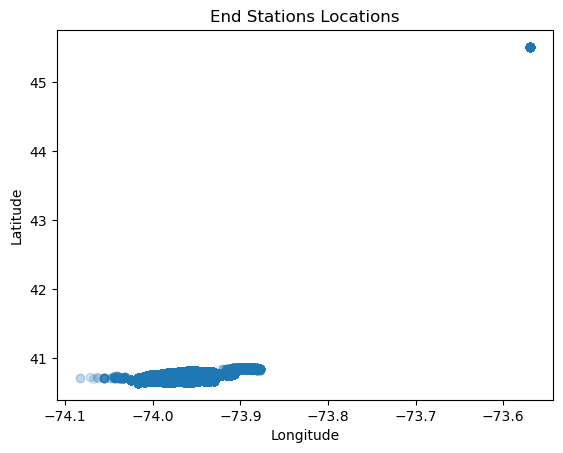

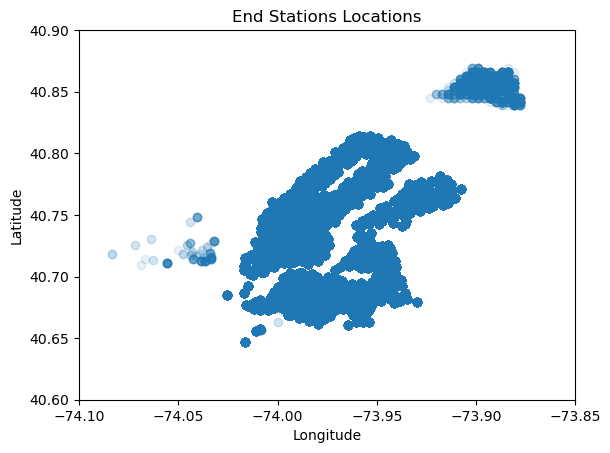

In [10]:
'''
  We see that the dataset have some outliers
'''
plt.scatter(data['end_station_longitude'], data['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
# plt.xlim([-74.1, -73.85])
plt.show()

plt.scatter(data['end_station_longitude'], data['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
plt.xlim([-74.1, -73.85])
plt.ylim([40.6, 40.9])
plt.show()

### Baseline model

We try making a baseline model by just picking 30 centroids to see what happens.

In [ ]:
# Prepare data for k-means
# Extract station_id, latitude and longitude st. we get all stations in the model
stations_start = data[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
stations_start.columns = ['station_id', 'latitude', 'longitude']

stations_end = data[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
stations_end.columns = ['station_id', 'latitude', 'longitude']
stations = pd.concat([stations_start, stations_end]).drop_duplicates().reset_index(drop=True)

# Remove outlier, we should add it again after traning the model
print(stations[stations['latitude'] > 44]['station_id'].unique())
stations = stations[stations['latitude'] <= 44]

[3488. 3650.]


In [28]:
print(stations.head())
print(stations.shape)

   station_id   latitude  longitude  station_cluster
0        72.0  40.767272 -73.993929                8
1        79.0  40.719116 -74.006667                2
2        82.0  40.711174 -74.000165                2
3        83.0  40.683826 -73.976323                6
4       119.0  40.696089 -73.978034                6
(955, 4)


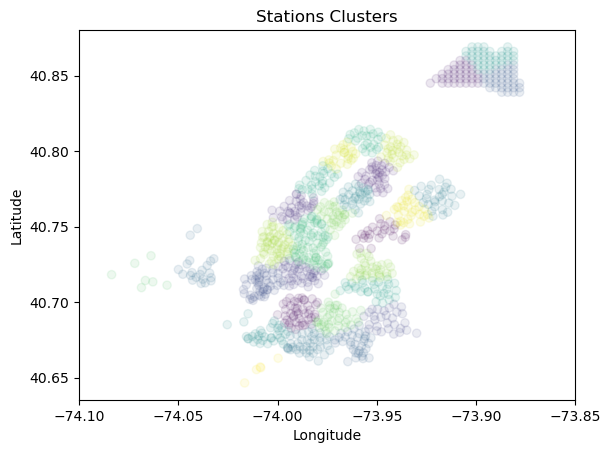

In [12]:
kmeans = KMeans(n_clusters=30)
stations['station_cluster'] = kmeans.fit_predict(stations[['longitude', 'latitude']])
plt.scatter(stations['longitude'], stations['latitude'], c=stations['station_cluster'], cmap='viridis', alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Stations Clusters')
plt.xlim([-74.1, -73.85])
plt.show()

### Finding the best model

In [13]:


'''
    We generated this function using CHATGPT to automaticaly find the elbow point
'''
def auto_elbow_k(
    ks: Iterable[float],
    inertias: Iterable[float],
    *,
    normalize: bool = True,
    return_details: bool = False,
) -> Tuple[float, Optional[int], Optional[np.ndarray]]:
    ks = np.asarray(ks, dtype=float)
    inertias = np.asarray(inertias, dtype=float)

    if ks.ndim != 1 or inertias.ndim != 1:
        raise ValueError("`ks` and `inertias` must be 1D sequences.")
    if ks.size != inertias.size or ks.size < 2:
        raise ValueError("`ks` and `inertias` must have the same length >= 2.")

    # Normalize to [0,1] for scale invariance (with safe guards)
    if normalize:
        x = ks.copy()
        y = inertias.copy()
        k_range = x.max() - x.min()
        i_range = y.max() - y.min()
        if k_range > 0:
            x = (x - x.min()) / k_range
        else:
            # All ks equal; just center to zero to avoid NaNs
            x = np.zeros_like(x)
        if i_range > 0:
            y = (y - y.min()) / i_range
        else:
            y = np.zeros_like(y)
    else:
        x = ks.astype(float, copy=True)
        y = inertias.astype(float, copy=True)

    # Line from first to last point
    p1 = np.array([x[0], y[0]], dtype=float)
    p2 = np.array([x[-1], y[-1]], dtype=float)
    line_vec = p2 - p1
    norm = np.linalg.norm(line_vec)
    if norm == 0:
        # If first and last are identical, distances reduce to distance from that point
        line_unit = np.array([1.0, 0.0])  # arbitrary; perpendicular distances still computed
    else:
        line_unit = line_vec / norm

    # Perpendicular distance from each point to the line
    points = np.stack([x, y], axis=1)
    vec_from_p1 = points - p1
    proj_len = np.dot(vec_from_p1, line_unit)        # shape (n,)
    proj = np.outer(proj_len, line_unit)             # shape (n,2)
    perp = vec_from_p1 - proj
    distances = np.linalg.norm(perp, axis=1)

    idx = int(np.argmax(distances))
    k_elbow = float(ks[idx])

    if return_details:
        return k_elbow, idx, distances
    else:
        return k_elbow, None, None

We try to find the best model using the elbow point, but we get this number to be very low. 

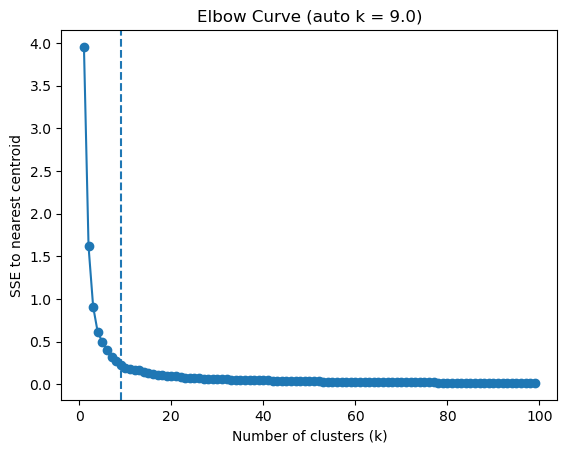

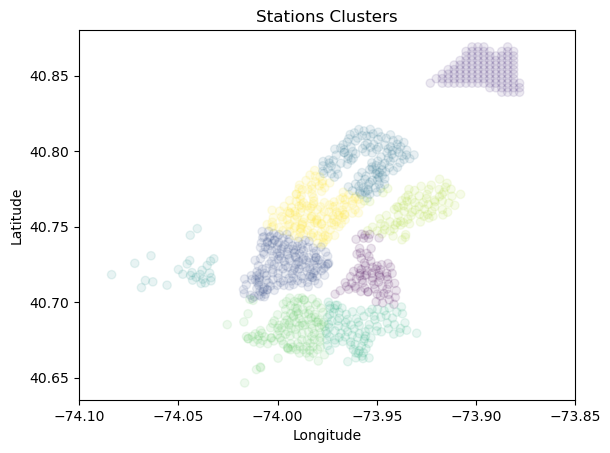

In [14]:
import numpy as np
from sklearn.cluster import KMeans
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# Fit a kmeans model for a range of k's
ks = np.arange(1, 100)
X = stations[['longitude', 'latitude']].to_numpy()
inertias = []
for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
inertias = np.array(inertias, dtype=float)


# Fit a model with the detected elbow k
k_elbow, idx, dists = auto_elbow_k(ks, inertias, return_details=True)
kmeans = KMeans(n_clusters=int(k_elbow), n_init='auto', random_state=42)
kmeans.fit(X)
stations['station_cluster'] = kmeans.fit_predict(stations[['longitude', 'latitude']])


# Plot elbow curve with detected elbow
plt.figure()
plt.plot(ks, inertias, marker='o')
plt.axvline(k_elbow, linestyle='--')
plt.title(f"Elbow Curve (auto k = {k_elbow})")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE to nearest centroid")
plt.show()

# Plot clusters
plt.scatter(stations['longitude'], stations['latitude'], c=stations['station_cluster'], cmap='viridis', alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Stations Clusters')
plt.xlim([-74.1, -73.85])
plt.show()


Using the same DBSCAN model as we used in the analysis we see how many clusters it suggests. We could of course get more clusters by tweaking the espilon parameter, but we need all stations to be within a cluster and do not care about noise.

DBSCAN clusters: 5
Noise points: 3.7%


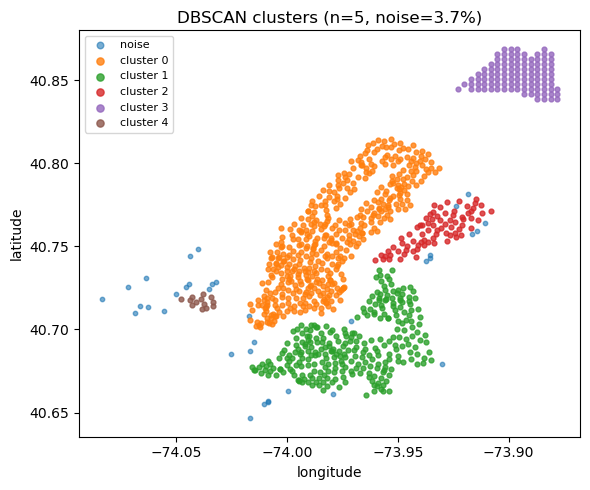

In [15]:


db = DBSCAN(eps = 0.005)
labels = db.fit_predict(stations[['longitude', 'latitude']].to_numpy())

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_frac = np.mean(labels == -1)

print(f"DBSCAN clusters: {n_clusters}")
print(f"Noise points: {noise_frac:.1%}")


plt.figure(figsize=(6, 5))
unique_labels = sorted(set(labels))
for lab in unique_labels:
    mask = labels == lab
    if lab == -1:
        plt.scatter(X[mask, 0], X[mask, 1], s=10, alpha=0.6, label='noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], s=12, alpha=0.8, label=f'cluster {lab}')
plt.title(f'DBSCAN clusters (n={n_clusters}, noise={noise_frac:.1%})')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.legend(markerscale=1.5, fontsize=8, frameon=True)
plt.tight_layout()
plt.show()


We will continue using the K-means model, and try to find a model that minimize within-cluster (inter-cluster) variability while maximizing the  between-cluster (intra-cluster) variability. To do this we use the measures distorstion and silhoutte.

Distortion is the summed distance between a point beloning in a cluster and the center of the cluster. And thereby is a measure of the within cluster variabiility.


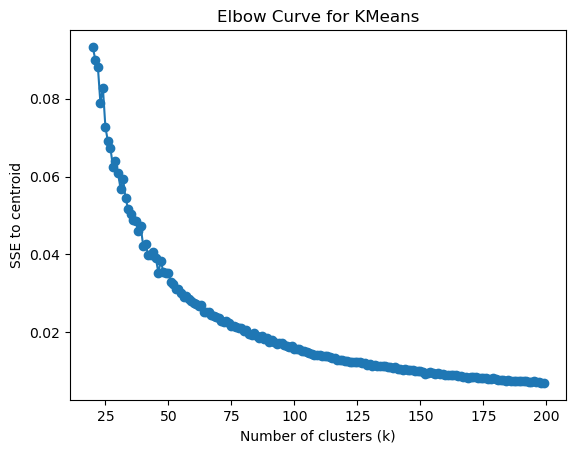

In [16]:
import numpy as np
from sklearn.cluster import KMeans
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# compute inertia for k values
ks = range(20, 200)
inertias = []
for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto')
    kmeans.fit(stations[['longitude', 'latitude']])
    inertias.append(kmeans.inertia_)

# plot elbow curve
plt.figure()
plt.plot(ks, inertias, marker='o')
plt.title("Elbow Curve for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE to centroid")
plt.show()


(955, 4)
Using k range: 20 to 199


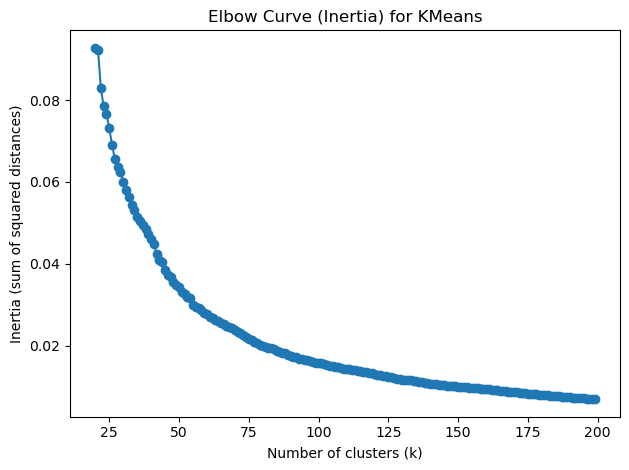

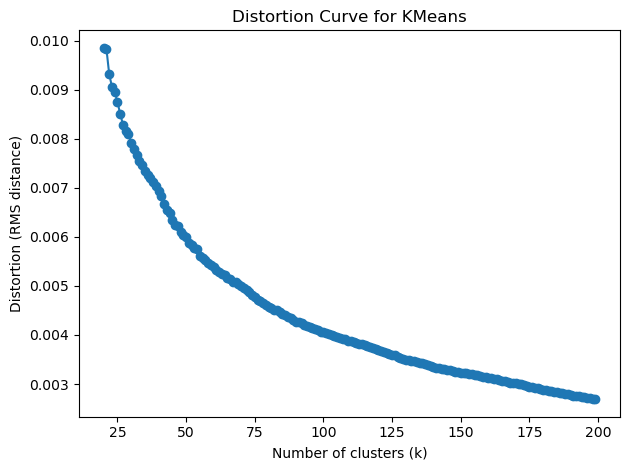

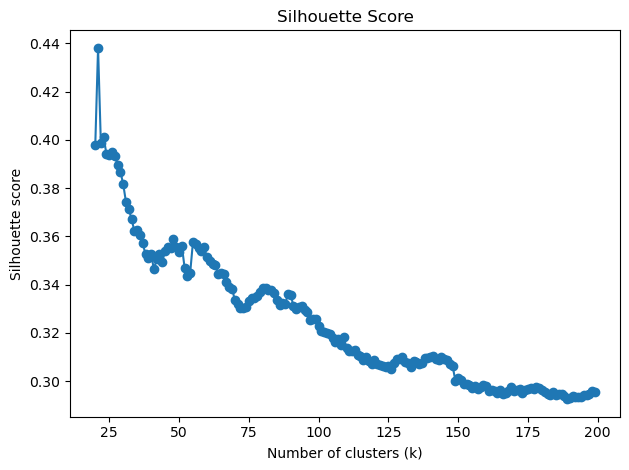

argmax index: 1, k: 21, silhouette: 0.438159, distortion: 0.009826


In [35]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=UserWarning)

print(stations.shape)

# --- Prepare data ---
X = stations[['longitude', 'latitude']].to_numpy()
n_samples = X.shape[0]

# Choose a sensible k range
k_min = 20
k_max = min(199, n_samples - 1)  # silhouette needs k < n_samples
print(f"Using k range: {k_min} to {k_max}")
ks = range(k_min, k_max + 1)

inertias = []
distortions = []   # sqrt(inertia / n_samples)
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(X)

    inertia = km.inertia_
    sil = silhouette_score(X, labels, metric='euclidean')
    inertias.append(inertia)
    distortions.append(np.sqrt(inertia / n_samples))  # "distortion" (RMS distance)
    silhouettes.append(sil)


# 1) Elbow: Inertia
plt.figure()
plt.plot(list(ks), inertias, marker='o')
plt.title("Elbow Curve (Inertia) for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.tight_layout()
plt.show()

# 2) Distortion (RMS distance to closest centroid)
plt.figure()
plt.plot(list(ks), distortions, marker='o')
plt.title("Distortion Curve for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (RMS distance)")
plt.tight_layout()
plt.show()

# 3) Silhouette score
plt.figure()
plt.plot(list(ks), silhouettes, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()


idx_max = int(np.argmax(silhouettes))
k_best = k_min + idx_max
print(f"argmax index: {idx_max}, k: {k_best}, silhouette: {silhouettes[idx_max]:.6f}, distortion: {distortions[idx_max]:.6f}")

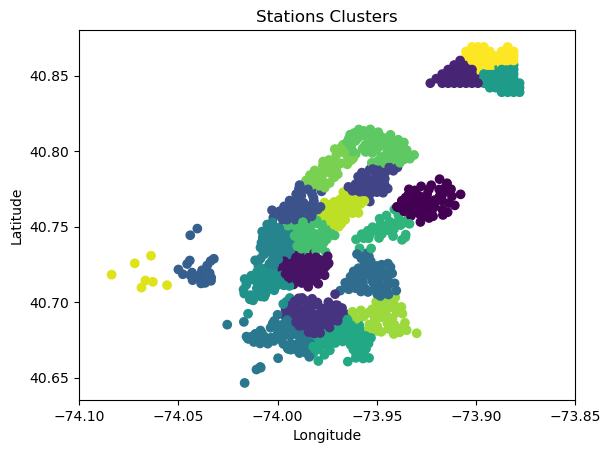

In [ ]:
kmeans = KMeans(n_clusters=21)
stations['station_cluster'] = kmeans.fit_predict(stations[['longitude', 'latitude']])
plt.scatter(stations['longitude'], stations['latitude'], c=stations['station_cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Stations Clusters')
plt.xlim([-74.1, -73.85])
plt.show()

### Postprocessing

In [18]:
# We add the clusters back to the dataframe based on where the journey start
data = data.merge(
    stations[['station_id', 'station_cluster']],
    how='left',
    left_on='start_station_id',
    right_on='station_id'
).rename(columns={'station_cluster': 'start_station_cluster'}).drop(columns=['station_id'])

# We get 47 nulls because we removed two outliers, we manually set it to the 30'th cluster st. we 31 in total
# Where startstation cluster = 3488 or 3650
print(data['start_station_cluster'].isnull().sum())
data.loc[data['start_station_id'] == 3488, 'start_station_cluster'] = stations['station_cluster'].max() + 1
data.loc[data['start_station_id'] == 3650, 'start_station_cluster'] = stations['station_cluster'].max() + 1
print(data['start_station_cluster'].isnull().sum())



81
0


In [19]:
print(data.head())
print(data.columns.tolist())


   Unnamed: 0  tripduration                 starttime  \
0           0           970  2018-01-01 13:50:57.4340   
1           1           723  2018-01-01 15:33:30.1820   
2           2           496  2018-01-01 15:39:18.3370   
3           3           306  2018-01-01 15:40:13.3720   
4           4           306  2018-01-01 18:14:51.5680   

                   stoptime  start_station_id  start_station_latitude  \
0  2018-01-01 14:07:08.1860              72.0               40.767272   
1  2018-01-01 15:45:33.3410              72.0               40.767272   
2  2018-01-01 15:47:35.1720              72.0               40.767272   
3  2018-01-01 15:45:20.1910              72.0               40.767272   
4  2018-01-01 18:19:57.6420              72.0               40.767272   

   start_station_longitude  end_station_id  end_station_latitude  \
0               -73.993929           505.0             40.749013   
1               -73.993929          3255.0             40.750585   
2             

In [20]:
# Based on the data dateframe plot the number of rows in each cluster

# New attempt with meters

In [21]:
import numpy as np
import pandas as pd

# Assuming `stations` already exists with columns: station_id, longitude, latitude

# Conversion factors
meters_per_degree_lat = 111_320

df = stations[['station_id', 'longitude', 'latitude']].copy()

# Convert degrees → meters
df['x_meters'] = df['longitude'] * meters_per_degree_lat * np.cos(np.deg2rad(df['latitude']))
df['y_meters'] = df['latitude'] * meters_per_degree_lat

df_meters = df[['station_id', 'x_meters', 'y_meters']]
print(df_meters)


     station_id      x_meters      y_meters
0          72.0 -6.238445e+06  4.538213e+06
1          79.0 -6.244038e+06  4.532852e+06
2          82.0 -6.244234e+06  4.531968e+06
3          83.0 -6.244786e+06  4.528924e+06
4         119.0 -6.243781e+06  4.530289e+06
..          ...           ...           ...
952      3639.0 -6.246351e+06  4.532867e+06
953         NaN -6.223566e+06  4.547867e+06
954      3277.0 -6.249542e+06  4.532322e+06
955         NaN -6.222925e+06  4.546531e+06
956      3279.0 -6.247455e+06  4.533132e+06

[955 rows x 3 columns]


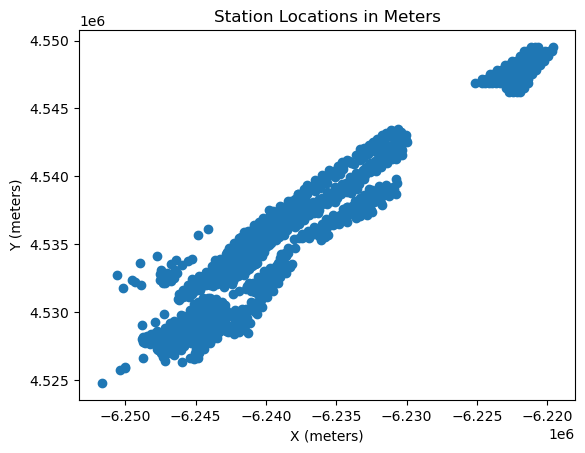

In [22]:
import matplotlib.pyplot as plt

plt.scatter(df_meters['x_meters'], df_meters['y_meters'])
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title("Station Locations in Meters")
plt.show()
